<a href="https://colab.research.google.com/github/ainan21/demo/blob/master/CNN_without_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive and Unzip file

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Locate zip file path
zip_path = "/content/drive/MyDrive/CNN Image Classification/cats_dogs_mini_dataset.zip"


In [ ]:
# Unzip file
import zipfile
import os

extract_path = "/content/cats_dogs"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")


Dataset unzipped successfully!


In [ ]:
#Check the actual folder structure
import os

for root, dirs, files in os.walk("/content/cats_dogs"):
    print(root, "→", len(files), "files")


/content/cats_dogs → 0 files
/content/cats_dogs/dogs_set → 500 files
/content/cats_dogs/cats_set → 500 files


# Import Libraries

In [ ]:
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load all dataset images and normalize

In [ ]:
data_dir = "/content/cats_dogs"
categories = ["cats_set", "dogs_set"]

data = []
labels = []

for cat in categories:
    path = os.path.join(data_dir, cat)
    for img_file in os.listdir(path):
        img_path = os.path.join(path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (32, 32))  # resize for faster computation
        data.append(img)
        labels.append(0 if cat == "cats_set" else 1)

data = np.array(data)
labels = np.array(labels)

# Normalize pixel values (0–1)
data = data / 255.0

print("Dataset loaded successfully!")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Dataset loaded successfully!
Data shape: (1000, 32, 32)
Labels shape: (1000,)


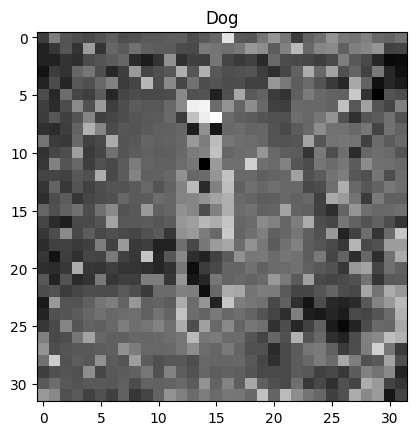

In [ ]:
# Visualize one image
import matplotlib.pyplot as plt
import random

index = random.randint(0, len(data)-1)
plt.imshow(data[index], cmap='gray')
plt.title("Cat" if labels[index] == 0 else "Dog")
plt.show()


# Split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Define simple convolution and ReLU functions

In [ ]:
def conv2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    img_height, img_width = image.shape
    output_height = img_height - kernel_height + 1
    output_width = img_width - kernel_width + 1
    output = np.zeros((output_height, output_width))
    for i in range(output_height):
        for j in range(output_width):
            output[i, j] = np.sum(image[i:i+kernel_height, j:j+kernel_width] * kernel)
    return output

def relu(x):
    return np.maximum(0, x)

# Define a simple CNN training loop (1 conv filter + 1 dense neuron)

In [ ]:
def simple_cnn_predict(image):
    # One convolution filter (edge detection)
    kernel = np.array([[1, 0, -1],
                       [1, 0, -1],
                       [1, 0, -1]])
    conv_out = conv2d(image, kernel)
    activated = relu(conv_out)
    pooled = activated[::2, ::2]  # simple 2x2 downsampling
    feature = pooled.flatten()
    return feature

# Extract features for all training and testing images


In [ ]:
X_train_features = np.array([simple_cnn_predict(img) for img in X_train])
X_test_features = np.array([simple_cnn_predict(img) for img in X_test])

# Train a simple dense layer manually (using linear regression idea)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(X_train_features, y_train)

y_pred = model.predict(X_test_features)
acc = accuracy_score(y_test, y_pred)
print("Accuracy (Manual CNN using NumPy):", acc)

Accuracy (Manual CNN using NumPy): 0.52
